# Foraging with training: learning the steering decision (Option 5)

This trains `learned_steering` with PPO on the `foraging` task and evaluates it. The
controller learns *only the steering decision* -- a tiny MLP mapping the egocentric
direction to the food into a turn command -- on top of the fixed NCAP turn primitive.

Two design choices make it learnable (both fixes for concrete failures earlier in this
project):
- **Warm start:** from random init PPO never even found the correct turn *sign* (~7%), so
  the controller is behaviour-cloned to the correct-sign hardcoded steerer first, and PPO
  refines from there.
- **Reward:** the swim-speed term is off (it rewards "swim fast" regardless of the food),
  leaving a dense **progress** reward (distance closed) plus an **eat bonus**.

Training ~1e5 steps takes a couple of minutes. Re-running skips training if the exact run
is already on disk.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import numpy as np
import matplotlib.pyplot as plt
from macrocircuits import ensure_tonic
ensure_tonic()

import torch, tonic, tonic.torch
from dm_control.mujoco import engine
from macrocircuits.models import ppo_swimmer_model
from macrocircuits.reflex_steering import make_steer_to_food_reflex
from macrocircuits.controllers import make_learned_steering
from macrocircuits.video import write_video
from IPython.display import Video

N_JOINTS = 5
SUCCESS_DIST = 0.15   # head within this of the food at some point => that episode found it
print('ready')

ready


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def _get_physics(env):
    while env is not None:
        if hasattr(env, 'physics'):
            return env.physics
        inner = getattr(env, 'environment', None)
        if inner is not None and hasattr(inner, 'physics'):
            return inner.physics
        env = getattr(env, 'env', None)
    raise RuntimeError('no physics in env chain')


def _arena_frame(physics, distance=5.5):
    """Fixed top-down camera on the whole arena, so you see the worm traverse to food."""
    cam = engine.Camera(physics, height=480, width=640, camera_id=-1)
    rc = cam._render_camera
    rc.lookat[:] = [0.0, 0.0, 0.0]
    rc.distance = distance; rc.azimuth = 90; rc.elevation = -90
    frame = cam.render(); cam._scene.free()
    return frame


def reflex_policy(controller, seed=0):
    """A deterministic policy from a FRESH (untrained) NCAP circuit + the given controller.
    Returns (policy, env, physics); `policy(obs)` -> action, both batched (1, .)."""
    torch.manual_seed(seed)
    model = ppo_swimmer_model(n_joints=N_JOINTS, critic_sizes=(256, 256),
                              action_noise=0.1, controller=controller)
    env = tonic.environments.distribute(
        lambda: tonic.environments.ControlSuite('swimmer-foraging', time_feature=True))
    env.initialize(seed)
    actor = model.actor
    actor.initialize(observation_space=env.observation_space, action_space=env.action_space)
    def policy(obs):
        with torch.no_grad():
            out = actor(torch.as_tensor(obs, dtype=torch.float32))
            return (out.loc if hasattr(out, 'loc') else out).numpy()
    return policy, env, _get_physics(env.environments[0])


def trained_policy(path, seed=0):
    """Load a PPO-trained checkpoint from `path` and return (policy, env, physics)."""
    import argparse, os, yaml
    import macrocircuits.training as _t
    ns = dict(vars(_t))
    cfg = argparse.Namespace(**yaml.load(open(os.path.join(path, 'config.yaml')), Loader=yaml.FullLoader))
    try:
        if cfg.header: exec(cfg.header, ns)
    except Exception:
        pass
    agent = eval(cfg.agent, ns)
    env = tonic.environments.distribute(lambda: eval(cfg.environment, ns))
    env.initialize(seed)
    agent.initialize(observation_space=env.observation_space,
                     action_space=env.action_space, seed=seed)
    cp = os.path.join(path, 'checkpoints')
    ids = [int(n.split('.')[0][5:]) for n in os.listdir(cp) if n.startswith('step_')]
    agent.load(os.path.join(cp, f'step_{max(ids)}'))
    return (lambda obs: agent.test_step(obs, 0)), env, _get_physics(env.environments[0])


def success_rate(policy, env, n_episodes=30):
    """Fraction of fresh episodes whose head comes within SUCCESS_DIST of the food.
    Distance is read from infos['observations'] (the pre-reset transition obs)."""
    tgt = slice(N_JOINTS, N_JOINTS + 2)
    obs = env.start(); mind = np.inf; hits = []
    while len(hits) < n_episodes:
        obs, infos = env.step(policy(obs))
        mind = min(mind, float(np.linalg.norm(infos['observations'][0, tgt])))
        if infos['resets'][0]:
            hits.append(mind < SUCCESS_DIST); mind = np.inf
    return float(np.mean(hits))


def forage_episode(policy, env, physics, steps=1000, viz_food_size=0.10):
    """One episode; records overhead frames, head path, food positions, and the steps
    where a food was reached (it then respawns). viz_food_size only enlarges the food
    marker for the video -- the success metric uses the true tiny food."""
    obs = env.start()
    if viz_food_size:
        physics.named.model.geom_size['target', 0] = viz_food_size; physics.forward()
    frames, hx, hy, fx, fy, eats = [], [], [], [], [], []
    prev_food = None
    for i in range(steps):
        frames.append(_arena_frame(physics))
        nose = physics.named.data.geom_xpos['nose'][:2].copy()
        food = physics.named.data.geom_xpos['target'][:2].copy()
        hx.append(nose[0]); hy.append(nose[1]); fx.append(food[0]); fy.append(food[1])
        if prev_food is not None and np.linalg.norm(food - prev_food) > 1e-6:
            eats.append(i)
        prev_food = food
        obs, infos = env.step(policy(obs))
        if infos['resets'][0]:
            break
    return dict(frames=frames, hx=np.array(hx), hy=np.array(hy),
                fx=np.array(fx), fy=np.array(fy), eats=eats)


def show_video(frames, path, fps=30):
    """Write the frames to an mp4 (imageio) and embed the file directly. This plays
    reliably in VSCode / Jupyter, unlike matplotlib's to_html5_video, which often renders
    blank or hangs in the VSCode notebook viewer."""
    import os
    os.makedirs(os.path.dirname(path), exist_ok=True)
    write_video(path, frames, fps=fps)
    return Video(path, embed=True, width=560)


def plot_path(ep, title):
    plt.figure(figsize=(6.5, 6.5))
    plt.scatter(ep['hx'], ep['hy'], c=np.arange(len(ep['hx'])), cmap='viridis', s=6, label='head path')
    food_pts = np.unique(np.c_[ep['fx'], ep['fy']], axis=0)
    plt.scatter(food_pts[:, 0], food_pts[:, 1], marker='*', s=260, c='red', ec='k', label='food', zorder=5)
    if ep['eats']:
        plt.scatter(ep['hx'][ep['eats']], ep['hy'][ep['eats']], s=90, c='lime', ec='k', label='reached', zorder=6)
    plt.gca().set_aspect('equal'); plt.grid(alpha=0.3); plt.legend()
    plt.title(title); plt.xlabel('world x'); plt.ylabel('world y'); plt.show()

print('helpers ready')

helpers ready


## Train

Declares one run and trains it (or reuses an existing checkpoint).

In [3]:
from macrocircuits.training import resolve_runs, run_config, run_path, is_trained, train

STEPS = int(1e5)   # bump for a longer run
RUN = resolve_runs([dict(
    network='ncap', method='ppo', task='foraging',
    controller='learned_steering',
    task_kwargs=dict(progress_reward_weight=10.0, eat_bonus=5.0),
    steps=STEPS, label='learned_steering_poc',
)])[0]

agent_s, env_s, name, trainer_s = run_config(**RUN)
path = run_path(**RUN)
if is_trained(path, agent_s, env_s, trainer_s):
    print('already trained at', path)
else:
    train(header='import tonic.torch', agent=agent_s, environment=env_s, name=name, trainer=trainer_s)
print('done ->', path)

already trained at data/local/experiments/tonic/swimmer-foraging/learned_steering_poc
done -> data/local/experiments/tonic/swimmer-foraging/learned_steering_poc


## Learning curve

Mean test-episode reward over training (from the run's `log.csv`).

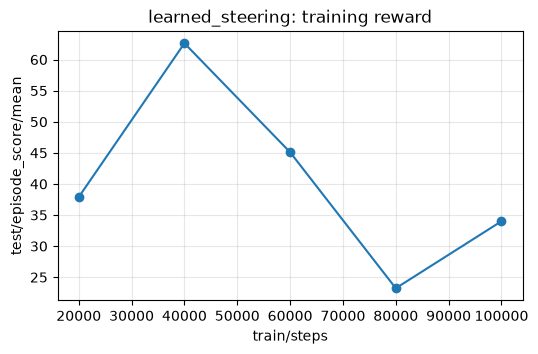

In [4]:
import pandas as pd, os
log = pd.read_csv(os.path.join(path, 'log.csv'))
col = next(c for c in log.columns if 'episode_score/mean' in c)
# Cumulative env steps. NOT 'train/epoch_steps', which is the constant epoch length
# (== the trainer's epoch_steps, e.g. 20000) and is identical at every eval point --
# plotting against it collapses the whole curve onto a single x. 'train/steps' is the
# monotonic counter; it ends with '/steps' whereas epoch_steps ends with '_steps'.
xcol = next(c for c in log.columns if c.endswith('/steps'))
plt.figure(figsize=(6, 3.5))
plt.plot(log[xcol], log[col], marker='o'); plt.xlabel(xcol); plt.ylabel(col)
plt.title('learned_steering: training reward'); plt.grid(alpha=0.3); plt.show()

## Evaluate the trained controller

Physics-only success of the trained checkpoint, next to the warm-started-but-untrained controller and no steering.

C:\Users\lukav\OneDrive\Documents\CogSci\projects\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-foraging/learned_steering_poc\checkpoints\step_100000.pt


no steering             : 23%
learned (warm, no RL)   : 80%
learned (PPO-trained)   : 93%


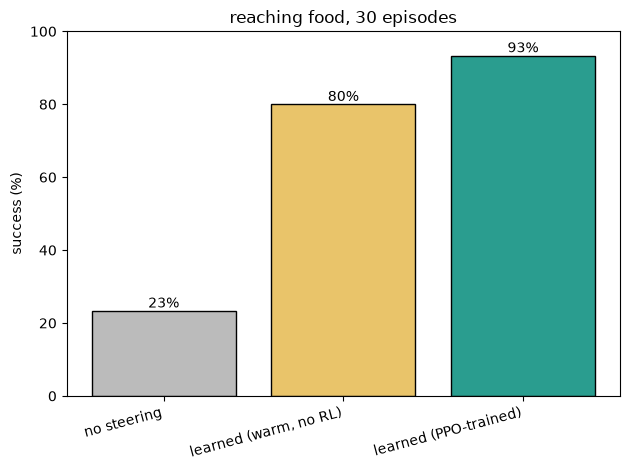

In [5]:
trained_pol, trained_env, trained_phys = trained_policy(path)
rates = {
    'no steering':                 success_rate(*reflex_policy(None)[:2]),
    'learned (warm, no RL)':       success_rate(*reflex_policy(make_learned_steering(N_JOINTS))[:2]),
    'learned (PPO-trained)':       success_rate(trained_pol, trained_env),
}
for k, v in rates.items(): print(f'{k:24}: {v*100:.0f}%')
bars = plt.bar(range(len(rates)), [v*100 for v in rates.values()],
               color=['#bbb', '#e9c46a', '#2a9d8f'], ec='k')
plt.xticks(range(len(rates)), list(rates), rotation=15, ha='right')
plt.bar_label(bars, fmt='%.0f%%'); plt.ylabel('success (%)'); plt.ylim(0, 100)
plt.title('reaching food, 30 episodes'); plt.tight_layout(); plt.show()

## Watch the trained controller forage

In [6]:
tp, te, tph = trained_policy(path, seed=3)
ep = forage_episode(tp, te, tph, steps=1000)
print(f'food reached this episode: {len(ep["eats"])}')
show_video(ep['frames'][::2], 'output_videos/forage_trained.mp4', fps=30)

C:\Users\lukav\OneDrive\Documents\CogSci\projects\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-foraging/learned_steering_poc\checkpoints\step_100000.pt


food reached this episode: 2


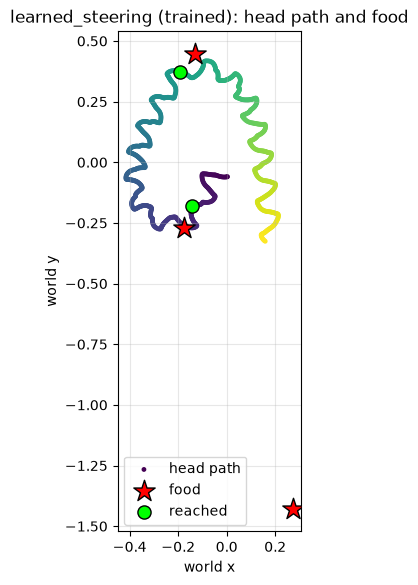

In [7]:
plot_path(ep, 'learned_steering (trained): head path and food')